In [1]:
# Chronis & Erk clustering method applied to Llama 3.1 8B Instruct
# SimLex-999 (similarity) and MEN (relatedness) datasets

In [1]:
import os
import csv
import torch
import sys
sys.path.insert(0, 'src')
import datasets
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
token = next(l.strip() for l in Path("hf_token.txt").read_text().splitlines() if l.strip().startswith("hf_"))
os.environ["HF_TOKEN"] = token
os.environ["HF_HOME"] = "D:/huggingface_cache"

In [4]:
print(torch.cuda.is_available())

True


In [5]:
from transformers import AutoModel, AutoTokenizer, AutoConfig, BitsAndBytesConfig

MODEL_DIR = Path("models/llama-3.1-8b-instruct")

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModel.from_pretrained(
    MODEL_DIR,
    quantization_config=bnb_config,
    device_map="auto",
)
model.eval()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] LlamaModel LOAD REPORT from: D:\252 Project\models\llama-3.1-8b-instruct
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LlamaModel(
  (embed_tokens): Embedding(128256, 4096)
  (layers): ModuleList(
    (0-31): 32 x LlamaDecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
        (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
        (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
        (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
        (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
    )
  )
  (norm): LlamaRMSNorm((4096,), eps=1e-05)
  (rotary_emb): LlamaRotaryEmbedding()
)

In [6]:
config = AutoConfig.from_pretrained(MODEL_DIR)
NUM_LAYERS = config.num_hidden_layers  # 32 for Llama 3.1 8B
print(f"Layers: {NUM_LAYERS}")
print(f"Hidden size: {config.hidden_size}")

Layers: 32
Hidden size: 4096


## SimLex-999 — Similarity

In [7]:
simlex999 = datasets.get_simlex999()
simlex999_wordlist = list(set(
    [row['word1'] for row in simlex999] + [row['word2'] for row in simlex999]
))

processed 999 word pairs from simlex999 dataset


In [8]:
def randomly(seq):
    import random
    shuffled = list(seq)
    random.shuffle(shuffled)
    return shuffled

def collect_bnc_examples(wordlist, max_num_examples=100):
    bnc_reader = datasets.get_bnc()
    print("BNC reader initialized, loading corpus...")
    corpus = bnc_reader.tagged_sents(strip_space=True)
    corpus_length = len(corpus)
    print(f"Corpus loaded: {corpus_length} sentences")

    unigrams = {word: max_num_examples for word in wordlist}
    bnc_examples = {word: [] for word in wordlist}
    randomized_indexes = randomly(range(corpus_length - 1))

    with tqdm(total=len(randomized_indexes), desc="BNC sentences") as pbar:
        while unigrams and randomized_indexes:
            sentence = corpus[randomized_indexes.pop()]
            pbar.update(1)
            pbar.set_postfix(words_remaining=len(unigrams))
            for word_tuple in sentence:
                word = word_tuple[0]
                if unigrams.get(word) and unigrams[word] > 0:
                    bnc_examples[word].append(' '.join([w[0] for w in sentence]))
                    unigrams[word] -= 1
                    if unigrams[word] == 0:
                        del unigrams[word]
    return bnc_examples

In [9]:
# Reuse GPT-2 pkl if available — BNC sentences are model-agnostic
if os.path.exists('bnc_examples.pkl'):
    with open('bnc_examples.pkl', 'rb') as f:
        bnc_examples = pickle.load(f)
    print("Loaded bnc_examples.pkl")
else:
    bnc_examples = collect_bnc_examples(simlex999_wordlist)
    with open('bnc_examples.pkl', 'wb') as f:
        pickle.dump(bnc_examples, f)

Loaded bnc_examples.pkl


In [10]:
warnings.filterwarnings("ignore", category=RuntimeWarning)
LLAMA_SIMLEX_PKL = 'all_layer_outputs_individual_llama_simlex.pkl'
BATCH_SIZE = 8
MAX_SENTENCES = 20

def embed_words_batched(wordlist, bnc_examples, model, tokenizer,
                        batch_size=BATCH_SIZE, checkpoint_path=None, checkpoint_every=50):
    if checkpoint_path and os.path.exists(checkpoint_path):
        try:
            with open(checkpoint_path, 'rb') as f:
                all_outputs = pickle.load(f)
            print(f"Resuming: {len(all_outputs)} words already done")
        except EOFError:
            print(f"Checkpoint {checkpoint_path} is corrupt, starting fresh")
            all_outputs = {}
    else:
        all_outputs = {}

    remaining = [w for w in wordlist if w not in all_outputs]
    print(f"Words to process: {len(remaining)}/{len(wordlist)}")

    for n, word in enumerate(tqdm(remaining, desc="Embedding words")):
        sentences = [s for s in bnc_examples.get(word, []) if word in s][:MAX_SENTENCES]
        word_vectors = []

        for i in range(0, len(sentences), batch_size):
            batch = sentences[i : i + batch_size]
            enc = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=1024,
                return_offsets_mapping=True,
            )
            offset_mapping = enc.pop("offset_mapping")

            batch_token_indices = []
            for j, sentence in enumerate(batch):
                word_start = sentence.index(word)
                word_end = word_start + len(word)
                indices = [
                    idx for idx, (tok_s, tok_e) in enumerate(offset_mapping[j].tolist())
                    if tok_s < word_end and tok_e > word_start and tok_s < tok_e
                ]
                batch_token_indices.append(indices)

            inputs = {k: v.to(model.device) for k, v in enc.items()}
            with torch.no_grad():
                model_output = model(**inputs, output_hidden_states=True)

            for j, indices in enumerate(batch_token_indices):
                if not indices:
                    continue
                layer_vecs = torch.stack([
                    layer_hidden[j, indices, :].mean(dim=0).cpu()
                    for layer_hidden in model_output.hidden_states
                ]).half()
                if not layer_vecs.isnan().any():
                    word_vectors.append(layer_vecs)

        if word_vectors:
            all_outputs[word] = torch.stack(word_vectors)

        if checkpoint_path and (n + 1) % checkpoint_every == 0:
            with open(checkpoint_path, 'wb') as f:
                pickle.dump(all_outputs, f)
            tqdm.write(f"Checkpoint saved ({len(all_outputs)} words)")

    if checkpoint_path:
        with open(checkpoint_path, 'wb') as f:
            pickle.dump(all_outputs, f)

    return all_outputs


all_layer_outputs_individual = embed_words_batched(
    simlex999_wordlist, bnc_examples, model, tokenizer,
    checkpoint_path=LLAMA_SIMLEX_PKL,
)
print("Done. Saved to", LLAMA_SIMLEX_PKL)

Resuming: 1028 words already done
Words to process: 0/1028


Embedding words: 0it [00:02, ?it/s]

Done. Saved to all_layer_outputs_individual_llama_simlex.pkl


In [11]:
from sklearn.cluster import KMeans

def get_word_clusters(word, layer_idx, K=4, outputs=None):
    if outputs is None:
        outputs = all_layer_outputs_individual
    X = outputs[word][:, layer_idx, :].float().cpu().numpy()
    k = min(K, X.shape[0])
    kmeans = KMeans(n_clusters=k).fit(X)
    return kmeans.cluster_centers_

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def max_sim(word1, word2, layer_idx, K=4, outputs=None):
    centroids1 = get_word_clusters(word1, layer_idx, K, outputs=outputs)
    centroids2 = get_word_clusters(word2, layer_idx, K, outputs=outputs)
    sims = [
        cosine_similarity(c1, c2)
        for c1 in centroids1
        for c2 in centroids2
    ]
    return max(sims)

In [12]:
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
# Per-layer Spearman rho on SimLex-999 (K=4)
valid_pairs_simlex = [
    (row['word1'], row['word2'])
    for row in simlex999
    if row['word1'] in all_layer_outputs_individual and row['word2'] in all_layer_outputs_individual
]
human_sims_simlex = [
    float(row['SimLex999'])
    for row in simlex999
    if row['word1'] in all_layer_outputs_individual and row['word2'] in all_layer_outputs_individual
]
print(f"Valid SimLex pairs: {len(valid_pairs_simlex)}/999")

for layer_idx in tqdm(range(NUM_LAYERS + 1), desc="Layers"):
    model_scores = [max_sim(w1, w2, layer_idx, K=4) for w1, w2 in valid_pairs_simlex]
    print(f"Layer {layer_idx} Spearman's p correlation is: {spearmanr(model_scores, human_sims_simlex)}")

Valid SimLex pairs: 999/999


Layers:   0%|          | 0/33 [00:00<?, ?it/s]

Layer 0 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.35953269786674824), pvalue=np.float64(7.5395326517598e-32))
Layer 1 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.4443465072304962), pvalue=np.float64(1.3615112860887059e-49))
Layer 2 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.44234688241337383), pvalue=np.float64(4.108924142976366e-49))
Layer 3 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.5298801028096529), pvalue=np.float64(2.1130744025875545e-73))
Layer 4 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.557275118072358), pvalue=np.float64(1.403921633333002e-82))
Layer 5 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.5751860611024974), pvalue=np.float64(4.6645910318676237e-89))
Layer 6 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.5872392010076715), pvalue=np.float64(1.1988034911032554e-93))
Layer 7 Spearman'

Loaded results/results_llama_simlex.csv


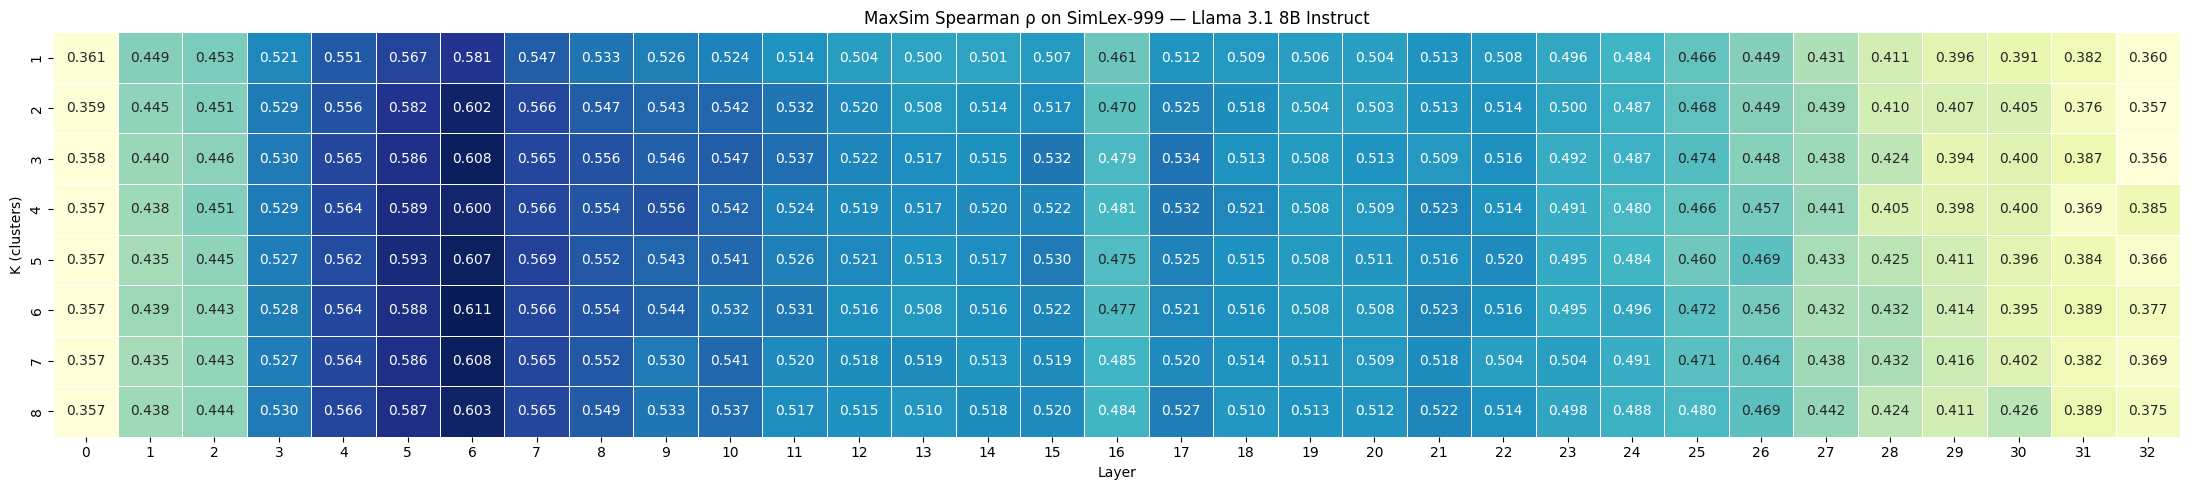

In [4]:
LLAMA_SIMLEX_CSV = 'results/results_llama_simlex.csv'

if os.path.exists(LLAMA_SIMLEX_CSV):
    df_heat_simlex = pd.read_csv(LLAMA_SIMLEX_CSV, index_col=0)
    df_heat_simlex.columns = df_heat_simlex.columns.astype(int)
    print(f"Loaded {LLAMA_SIMLEX_CSV}")
else:
    K_values = [1, 2, 3, 4, 5, 6, 7, 8]
    heatmap_data_simlex = []

    for K in tqdm(K_values, desc="K values"):
        for layer_idx in tqdm(range(NUM_LAYERS + 1), desc=f"K={K} layers", leave=False):
            model_scores = [max_sim(w1, w2, layer_idx, K=K) for w1, w2 in valid_pairs_simlex]
            rho, _ = spearmanr(model_scores, human_sims_simlex)
            heatmap_data_simlex.append({'k_clusters': K, 'layer': layer_idx, 'spearman': round(rho, 3)})

    df_heat_simlex = pd.DataFrame(heatmap_data_simlex).pivot(index='k_clusters', columns='layer', values='spearman')
    df_heat_simlex.to_csv(LLAMA_SIMLEX_CSV)
    print(f"Saved {LLAMA_SIMLEX_CSV}")

fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(df_heat_simlex, annot=True, fmt='.3f', linewidths=0.5, ax=ax, cmap='YlGnBu', square=False, cbar=False)
ax.set_title('MaxSim Spearman ρ on SimLex-999 — Llama 3.1 8B Instruct')
ax.set_xlabel('Layer')
ax.set_ylabel('K (clusters)')
plt.tight_layout()
plt.savefig('results/llama_simlex_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## MEN — Relatedness

In [14]:
men = datasets.get_men()
men_wordlist = list(set([row['word1'] for row in men] + [row['word2'] for row in men]))
men_new_words = [w for w in men_wordlist if w not in all_layer_outputs_individual]
print(f"MEN unique words: {len(men_wordlist)}, new (not yet embedded): {len(men_new_words)}")

processed 3000 word pairs from MEN relatedness dataset
MEN unique words: 751, new (not yet embedded): 524


In [15]:
MEN_BNC_PKL = 'bnc_examples_men.pkl'
LLAMA_MEN_PKL = 'all_layer_outputs_individual_llama_men.pkl'

if os.path.exists(MEN_BNC_PKL):
    with open(MEN_BNC_PKL, 'rb') as f:
        bnc_examples_men = pickle.load(f)
    print("Loaded bnc_examples_men.pkl")
else:
    bnc_examples_men = collect_bnc_examples(men_new_words)
    with open(MEN_BNC_PKL, 'wb') as f:
        pickle.dump(bnc_examples_men, f)

all_layer_outputs_individual_men = embed_words_batched(
    men_new_words, bnc_examples_men, model, tokenizer,
    checkpoint_path=LLAMA_MEN_PKL,
)
print("Done. Saved to", LLAMA_MEN_PKL)

all_layer_outputs_individual_combined = {**all_layer_outputs_individual, **all_layer_outputs_individual_men}
print(f"Combined vocab size: {len(all_layer_outputs_individual_combined)}")

Loaded bnc_examples_men.pkl
Resuming: 523 words already done
Words to process: 1/524


Embedding words:   0%|          | 0/1 [00:00<?, ?it/s]

Done. Saved to all_layer_outputs_individual_llama_men.pkl
Combined vocab size: 1551


In [16]:
# Per-layer Spearman rho on MEN (K=4)
valid_pairs_men = [
    (row['word1'], row['word2'])
    for row in men
    if row['word1'] in all_layer_outputs_individual_combined and row['word2'] in all_layer_outputs_individual_combined
]
human_sims_men = [
    row['relatedness']
    for row in men
    if row['word1'] in all_layer_outputs_individual_combined and row['word2'] in all_layer_outputs_individual_combined
]
print(f"Valid MEN pairs: {len(valid_pairs_men)}/3000")

for layer_idx in tqdm(range(NUM_LAYERS + 1), desc="Layers"):
    model_scores = [max_sim(w1, w2, layer_idx, K=4, outputs=all_layer_outputs_individual_combined)
                    for w1, w2 in valid_pairs_men]
    print(f"Layer {layer_idx} Spearman's p correlation is: {spearmanr(model_scores, human_sims_men)}")

Valid MEN pairs: 2998/3000


Layers:   0%|          | 0/33 [00:00<?, ?it/s]

Layer 0 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.5801906629066546), pvalue=np.float64(2.5039829158525667e-269))
Layer 1 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.5920061372938976), pvalue=np.float64(4.606739950442587e-283))
Layer 2 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6098787665959611), pvalue=np.float64(5.906102931053614e-305))
Layer 3 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6982732695854728), pvalue=np.float64(0.0))
Layer 4 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.7394671160772426), pvalue=np.float64(0.0))
Layer 5 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.7664946172030955), pvalue=np.float64(0.0))
Layer 6 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.7699913905328603), pvalue=np.float64(0.0))
Layer 7 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.736147143

Loaded results/results_llama_men.csv


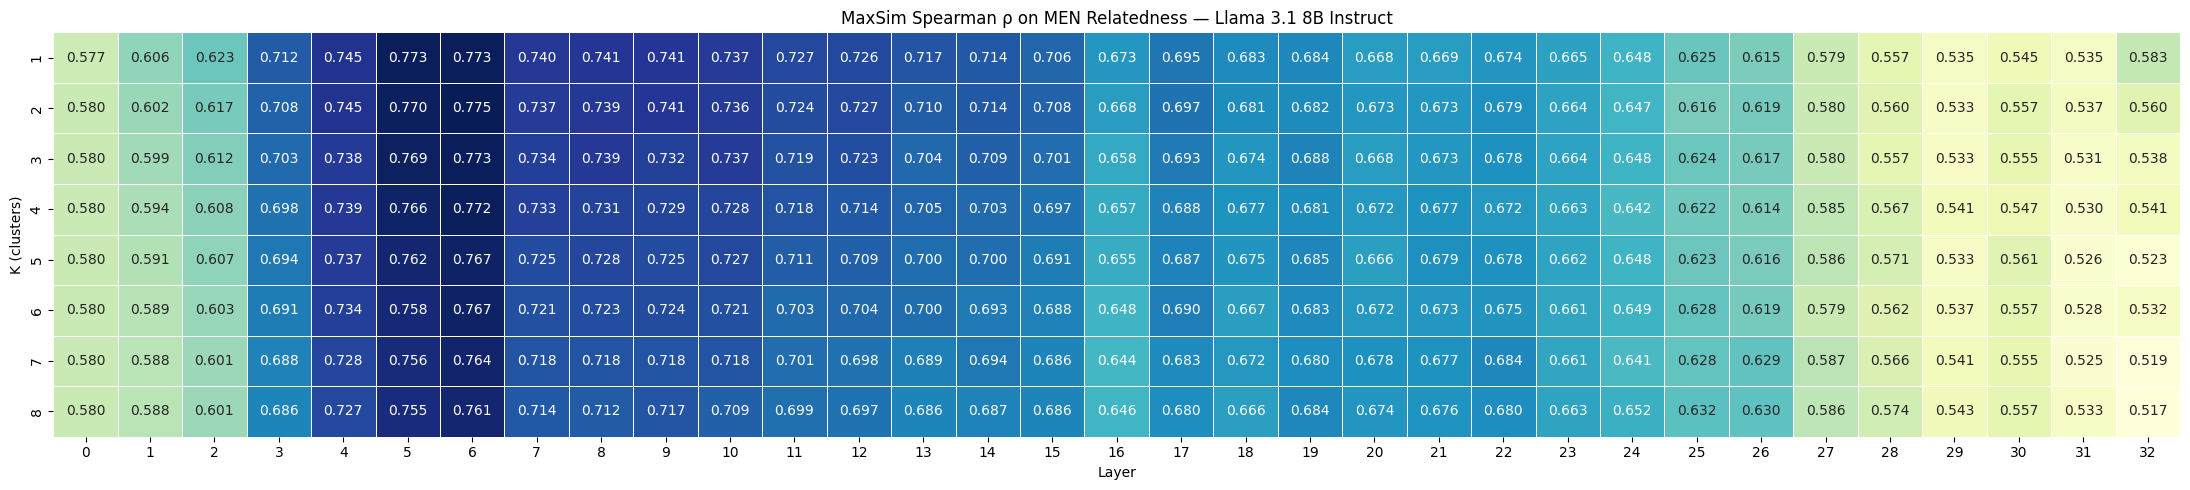

In [5]:
LLAMA_MEN_CSV = 'results/results_llama_men.csv'

if os.path.exists(LLAMA_MEN_CSV):
    df_heat_men = pd.read_csv(LLAMA_MEN_CSV, index_col=0)
    df_heat_men.columns = df_heat_men.columns.astype(int)
    print(f"Loaded {LLAMA_MEN_CSV}")
else:
    K_values = [1, 2, 3, 4, 5, 6, 7, 8]
    heatmap_data_men = []

    for K in tqdm(K_values, desc="K values"):
        for layer_idx in tqdm(range(NUM_LAYERS + 1), desc=f"K={K} layers", leave=False):
            model_scores = [max_sim(w1, w2, layer_idx, K=K, outputs=all_layer_outputs_individual_combined)
                            for w1, w2 in valid_pairs_men]
            rho, _ = spearmanr(model_scores, human_sims_men)
            heatmap_data_men.append({'k_clusters': K, 'layer': layer_idx, 'spearman': round(rho, 3)})

    df_heat_men = pd.DataFrame(heatmap_data_men).pivot(index='k_clusters', columns='layer', values='spearman')
    df_heat_men.to_csv(LLAMA_MEN_CSV)
    print(f"Saved {LLAMA_MEN_CSV}")

fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(df_heat_men, annot=True, fmt='.3f', linewidths=0.5, ax=ax, cmap='YlGnBu', square=False, cbar=False)
ax.set_title('MaxSim Spearman ρ on MEN Relatedness — Llama 3.1 8B Instruct')
ax.set_xlabel('Layer')
ax.set_ylabel('K (clusters)')
plt.tight_layout()
plt.savefig('results/llama_men_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Save heatmap results to CSV for cross-notebook comparison
df_heat_simlex.to_csv('results/results_llama_simlex.csv')
df_heat_men.to_csv('results/results_llama_men.csv')
print("Saved results_llama_simlex.csv and results_llama_men.csv")

Saved results_llama_simlex.csv and results_llama_men.csv


## Comparison with simple contextualized embeddings

In [19]:
# Simple contextualized embeddings: "The {} is here."
TEMPLATE = "The {} is here."
SIMPLE_PKL = 'simple_template_embeddings_llama.pkl'

def embed_words_simple(wordlist, model, tokenizer, template=TEMPLATE):
    embeddings = {}
    for word in tqdm(wordlist, desc="Embedding words"):
        sentence = template.format(word)
        enc = tokenizer(sentence, return_tensors="pt", return_offsets_mapping=True)
        offset_mapping = enc.pop("offset_mapping")[0]

        word_start = sentence.index(word)
        word_end = word_start + len(word)
        indices = [
            idx for idx, (tok_s, tok_e) in enumerate(offset_mapping.tolist())
            if tok_s < word_end and tok_e > word_start and tok_s < tok_e
        ]
        if not indices:
            continue

        inputs = {k: v.to(model.device) for k, v in enc.items()}
        with torch.no_grad():
            output = model(**inputs, output_hidden_states=True)

        layer_vecs = torch.stack([
            layer_hidden[0, indices, :].mean(dim=0).cpu()
            for layer_hidden in output.hidden_states
        ])
        embeddings[word] = layer_vecs
    return embeddings

if os.path.exists(SIMPLE_PKL):
    with open(SIMPLE_PKL, 'rb') as f:
        simple_embeddings = pickle.load(f)
    print(f"Loaded {SIMPLE_PKL}: {len(simple_embeddings)} words")
else:
    all_words = list(set(simlex999_wordlist + men_wordlist))
    simple_embeddings = embed_words_simple(all_words, model, tokenizer)
    with open(SIMPLE_PKL, 'wb') as f:
        pickle.dump(simple_embeddings, f)
    print(f"Saved {SIMPLE_PKL}")

Loaded simple_template_embeddings_llama.pkl: 1552 words


Loaded results_llama_simple_simlex.csv


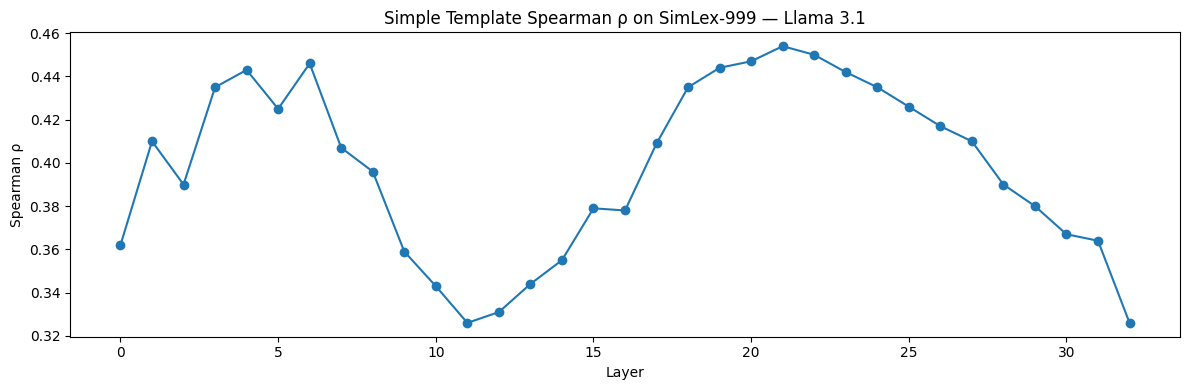

In [20]:
SIMPLE_SIMLEX_CSV = 'results/results_llama_simple_simlex.csv'

if os.path.exists(SIMPLE_SIMLEX_CSV):
    df_simple_simlex = pd.read_csv(SIMPLE_SIMLEX_CSV, index_col=0)
    print(f"Loaded {SIMPLE_SIMLEX_CSV}")
else:
    valid_pairs_simple = [
        (row['word1'], row['word2'])
        for row in simlex999
        if row['word1'] in simple_embeddings and row['word2'] in simple_embeddings
    ]
    human_sims_simple = [
        float(row['SimLex999'])
        for row in simlex999
        if row['word1'] in simple_embeddings and row['word2'] in simple_embeddings
    ]
    print(f"Valid pairs: {len(valid_pairs_simple)}/999")

    results = []
    for layer_idx in tqdm(range(NUM_LAYERS + 1), desc="Layers"):
        model_scores = [
            float(torch.nn.functional.cosine_similarity(
                simple_embeddings[w1][layer_idx].unsqueeze(0),
                simple_embeddings[w2][layer_idx].unsqueeze(0)
            ))
            for w1, w2 in valid_pairs_simple
        ]
        rho, _ = spearmanr(model_scores, human_sims_simple)
        results.append({'layer': layer_idx, 'spearman': round(rho, 3)})

    df_simple_simlex = pd.DataFrame(results).set_index('layer')
    df_simple_simlex.to_csv(SIMPLE_SIMLEX_CSV)
    print(f"Saved {SIMPLE_SIMLEX_CSV}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_simple_simlex.index, df_simple_simlex['spearman'], marker='o')
ax.set_title('Simple Template Spearman ρ on SimLex-999 — Llama 3.1')
ax.set_xlabel('Layer')
ax.set_ylabel('Spearman ρ')
plt.tight_layout()
plt.show()

Loaded results_llama_simple_men.csv


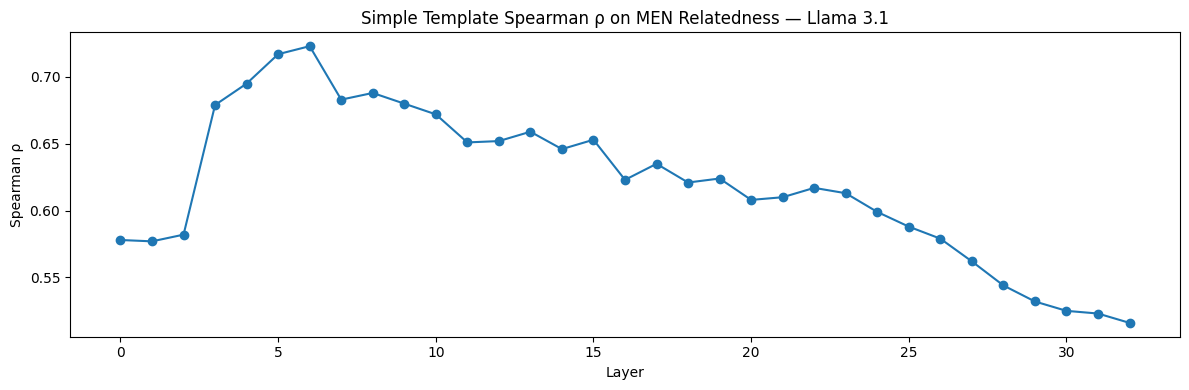

In [21]:
SIMPLE_MEN_CSV = 'results/results_llama_simple_men.csv'

if os.path.exists(SIMPLE_MEN_CSV):
    df_simple_men = pd.read_csv(SIMPLE_MEN_CSV, index_col=0)
    print(f"Loaded {SIMPLE_MEN_CSV}")
else:
    valid_pairs_simple_men = [
        (row['word1'], row['word2'])
        for row in men
        if row['word1'] in simple_embeddings and row['word2'] in simple_embeddings
    ]
    human_sims_simple_men = [
        row['relatedness']
        for row in men
        if row['word1'] in simple_embeddings and row['word2'] in simple_embeddings
    ]
    print(f"Valid MEN pairs: {len(valid_pairs_simple_men)}/3000")

    results_men = []
    for layer_idx in tqdm(range(NUM_LAYERS + 1), desc="Layers"):
        model_scores = [
            float(torch.nn.functional.cosine_similarity(
                simple_embeddings[w1][layer_idx].unsqueeze(0),
                simple_embeddings[w2][layer_idx].unsqueeze(0)
            ))
            for w1, w2 in valid_pairs_simple_men
        ]
        rho, _ = spearmanr(model_scores, human_sims_simple_men)
        results_men.append({'layer': layer_idx, 'spearman': round(rho, 3)})

    df_simple_men = pd.DataFrame(results_men).set_index('layer')
    df_simple_men.to_csv(SIMPLE_MEN_CSV)
    print(f"Saved {SIMPLE_MEN_CSV}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_simple_men.index, df_simple_men['spearman'], marker='o')
ax.set_title('Simple Template Spearman ρ on MEN Relatedness — Llama 3.1')
ax.set_xlabel('Layer')
ax.set_ylabel('Spearman ρ')
plt.tight_layout()
plt.show()

## Non-contextual Baselines

Each word is embedded in isolation (no surrounding context). Two variants:
- **Layer 0** (`hidden_states[0]`): token embedding before any transformer layers
- **Final layer** (`last_hidden_state`): full model pass with no context

Spearman ρ against SimLex-999 and MEN. Results saved to `results_llama_nonctx.csv`.

In [22]:
NONCTX_CSV = 'results/results_llama_nonctx.csv'

if os.path.exists(NONCTX_CSV):
    df_nonctx = pd.read_csv(NONCTX_CSV, index_col=0)
    print(f"Loaded {NONCTX_CSV}")
else:
    all_words = list(set(simlex999_wordlist + men_wordlist))
    initial_embs, final_embs = {}, {}

    for word in tqdm(all_words, desc="Non-contextual embeddings"):
        inputs = tokenizer(word, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model(**inputs, output_hidden_states=True)
        initial_embs[word] = out.hidden_states[0][0].mean(dim=0).float().cpu()
        final_embs[word] = out.last_hidden_state[0].mean(dim=0).float().cpu()

    def _spearman_cosine(embs, dataset, score_field):
        sims, human = [], []
        for r in dataset:
            w1, w2 = r['word1'], r['word2']
            if w1 in embs and w2 in embs:
                sims.append(torch.nn.functional.cosine_similarity(
                    embs[w1].unsqueeze(0), embs[w2].unsqueeze(0)
                ).item())
                human.append(float(r[score_field]))
        rho, _ = spearmanr(sims, human)
        return round(rho, 4)

    df_nonctx = pd.DataFrame([
        {'embedding': 'initial_layer_0',
         'simlex_rho': _spearman_cosine(initial_embs, simlex999, 'SimLex999'),
         'men_rho':    _spearman_cosine(initial_embs, men, 'relatedness')},
        {'embedding': 'final_layer',
         'simlex_rho': _spearman_cosine(final_embs, simlex999, 'SimLex999'),
         'men_rho':    _spearman_cosine(final_embs, men, 'relatedness')},
    ]).set_index('embedding')
    df_nonctx.to_csv(NONCTX_CSV)
    print(f"Saved {NONCTX_CSV}")

display(df_nonctx)

Non-contextual embeddings:   0%|          | 0/1552 [00:00<?, ?it/s]

Saved results_llama_nonctx.csv


,simlex_rho,men_rho
embedding,,
initial_layer_0,-0.0921,0.0989
final_layer,0.1393,0.3262
